# Model Iteration Notebook 

In this notebook, we will focus on training and evaluating multiple machine learning models to classify emotions in transcribed television show data. 

The different secitons in this notebook will help demonstrate how different models perform on the same dataset and will provide insights into model selection and optimization. 

For every type of model and/or iteration that we did, we tracked the details in the model iteration file that you can find attached to the final assignment on Brightspace or here [Model Iteration File](link-here). In order to improve our models, we used (a selection of) traditional NLP features that we extracted in the ‘NLP Features’ task [NLP Features.ipynb notebook](NLP Features.ipynb). 



In [1]:
# Configure logging to suppress INFO messages from different libraries
import logging
logging.basicConfig()
logger = logging.getLogger()
logger.setLevel(logging.WARNING)

In [2]:
import sys
import os

# Get the directory of the current notebook (which is /notebooks/)
# and navigate up one level (to /project_root/) to find /src
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add the project root to the system path
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
import numpy as np
import pandas as pd
from typing import Dict
from collections import Counter
import json

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import normalize

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Set Keras Backend to use PyTorch
os.environ["KERAS_BACKEND"] = "torch"
import keras
import torch
import torch.nn as nn

print("Torch version:",torch.__version__)

print("Is CUDA enabled?",torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Torch version: 2.9.0+cu126
Is CUDA enabled? True


In [5]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    AutoConfig, 
    EarlyStoppingCallback
)
import evaluate

c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



In [6]:
# Emotion Map obtained from https://aclanthology.org/I17-1099/ --> readme.txt
EMOTION_MAP: Dict[int, str] = {
    0: "neutral", 1: "anger", 2: "disgust", 3: "fear",
    4: "happiness", 5: "sadness", 6: "surprise"
}

In [7]:
df_concat = pd.read_csv(r"..\Data\CSV\sentiment_data\final_dataset.csv")

## Transformer Models 

In [8]:
# Balance dataset (you can adjust n=5000)
transformers_data = []
unique_emotions = df_concat['Emotion'].unique()

for emotion in unique_emotions:
    emotion_rows = df_concat[df_concat['Emotion'] == emotion]
    sampled_rows = emotion_rows.sample(n=7500, replace=True, random_state=42)
    transformers_data.append(sampled_rows)

transformers_data = pd.concat(transformers_data, ignore_index=True)
transformers_data['Emotion_ID'] = transformers_data['Emotion_ID'].astype(int)
transformers_data = transformers_data.drop(columns=['Unnamed: 0', 'Emotion'], errors='ignore')

In [9]:
transformer_data = df_concat.copy()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    transformers_data['Sentence'],
    transformers_data['Emotion_ID'],
    test_size=0.2,
    random_state=42,
    stratify=transformers_data['Emotion_ID'],
    shuffle=True
)

In [11]:
predictions = {}

In [12]:
# Data Preparation & Tokenization
def tokenize_data(checkpoint, X_train, y_train, X_test, y_test):
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)

    def tokenize_function(example):
        return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)

    train_df = pd.DataFrame({"text": X_train, "label": y_train})
    test_df = pd.DataFrame({"text": X_test, "label": y_test})

    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_test = test_dataset.map(tokenize_function, batched=True)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    return tokenizer, tokenized_train, tokenized_test, data_collator

In [13]:
def create_model_and_config(checkpoint, num_labels=7, freeze_model=False, 
                            unfreeze_classifier=False, num_unfrozen_encoder_layers=0):
    
    config = AutoConfig.from_pretrained(checkpoint, num_labels=num_labels)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        config=config,
        ignore_mismatched_sizes=True
    )
    
    # 1. Option to Freeze ALL parameters (except the classification head by default)
    if freeze_model:
        print("Freezing all parameters in the model body...")
        for name, param in model.named_parameters():
            param.requires_grad = False
    
    # 2. Unfreeze the final classification head
    if unfreeze_classifier:
        print("Unfreezing the final classification head (model.classifier/model.logits)...")
        # Most models (like RoBERTa and DistilBERT) use 'classifier' or 'pre_classifier'/'classifier'
        # or have the final layer accessible. We iterate over all named parameters 
        # to ensure it works across different architectures.
        for name, param in model.named_parameters():
            if 'classifier' in name or 'logits' in name:
                 param.requires_grad = True

    # 3. Unfreeze the LAST N encoder layers
    if num_unfrozen_encoder_layers > 0:
        print(f"Unfreezing the LAST {num_unfrozen_encoder_layers} encoder layers...")
        
        # Access the encoder layers based on known HUGGINGFACE conventions
        # This part requires some model-specific logic or a more general approach
        # For simplicity and coverage of common models (RoBERTa, BERT, DistilBERT):
        if hasattr(model, 'roberta'): # For RoBERTa-like models
            encoder_layers = model.roberta.encoder.layer
        elif hasattr(model, 'distilbert'): # For DistilBERT-like models
            encoder_layers = model.distilbert.transformer.layer
        elif hasattr(model, 'bert'): # For BERT-like models
             encoder_layers = model.bert.encoder.layer
        else:
             print("Warning: Could not identify encoder structure for unfreezing.")
             encoder_layers = []

        total_layers = len(encoder_layers)
        start_index = max(0, total_layers - num_unfrozen_encoder_layers)

        for i in range(start_index, total_layers):
            layer = encoder_layers[i]
            for param in layer.parameters():
                param.requires_grad = True

    return model

def create_training_args():
    return TrainingArguments(
        output_dir="./transformer-outputs",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=1e-4,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        num_train_epochs=100,
        fp16=True,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        logging_dir="./logs",
        logging_steps=50
    )

In [14]:
# Evaluation Metrics
def compute_metrics(eval_pred):
    accuracy_metric = evaluate.load("accuracy")
    f1_metric = evaluate.load("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")

    return {"accuracy": acc["accuracy"], "f1_weighted": f1["f1"]}

In [15]:
# Trainer Setup
def setup_trainer(model, tokenizer, training_args, train_set, test_set, data_collator):
    return Trainer(
        model=model,
        args=training_args,
        train_dataset=train_set,
        eval_dataset=test_set,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

In [16]:
def load_or_train_model(base_checkpoint, fallback_checkpoint,
                        X_train, y_train, X_test, y_test, show_params=False,
                        unfreeze_classifier=False, num_unfrozen_encoder_layers=0): # <--- New Parameters
    
    model_exists = os.path.exists(base_checkpoint)

    try:
        print(f"Loading tokenizer and model from {base_checkpoint}...")
        # Tokenizer is always loaded from the checkpoint or fallback
        tokenizer, train_ds, test_ds, collator = tokenize_data(base_checkpoint, X_train, y_train, X_test, y_test)
        
        # 1. Load trained model directly if it exists
        model = AutoModelForSequenceClassification.from_pretrained(base_checkpoint)
        
    except OSError:
        print(f"Failed to load {base_checkpoint}, falling back to {fallback_checkpoint}...")
        tokenizer, train_ds, test_ds, collator = tokenize_data(fallback_checkpoint, X_train, y_train, X_test, y_test)
        
        # 2. Create and configure a NEW model from the fallback checkpoint
        # This is where the unfreezing logic is applied for NEW models
        model = create_model_and_config(
            fallback_checkpoint, 
            num_labels=7, # Assuming 7 labels from config function
            freeze_model=True, # Often set to True when unfreezing specific layers
            unfreeze_classifier=unfreeze_classifier, # <--- Pass the new flags
            num_unfrozen_encoder_layers=num_unfrozen_encoder_layers # <--- Pass the new flags
        )
        model_exists = False # Model is being created, so set this for training

    if show_params:
        # This will now reflect the parameters set by the unfreezing logic
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"✅ Total Trainable Parameters: {trainable_params }")

    training_args = create_training_args()
    trainer = setup_trainer(model, tokenizer, training_args, train_ds, test_ds, collator)

    if model_exists:
        print("The model was loaded successfully (no training needed).")
    else:
        # Train new model
        print("Training new model...")
        trainer.train()

        # Save the model and tokenizer
        print(f"Saving trained model to {base_checkpoint}...")
        trainer.save_model(base_checkpoint)

    return model, tokenizer, trainer, train_ds, test_ds

In [76]:
checkpoint = "transformer-models/distilbert-base"
fallback = "distilbert-base-uncased-finetuned-sst-2-english"

model, tokenizer, trainer, train_ds, test_ds = load_or_train_model(
    base_checkpoint=checkpoint,
    fallback_checkpoint=fallback,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    show_params=True,
    unfreeze_classifier=True
)

Loading tokenizer and model from transformer-models/distilbert-base...
Failed to load transformer-models/distilbert-base, falling back to distilbert-base-uncased-finetuned-sst-2-english...


Map: 100%|██████████| 10500/10500 [00:00<00:00, 16195.97 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased-finetuned-sst-2-english and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([7]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([7, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Freezing all parameters in the model body...
Unfreezing the final classification head (model.classifier/model.logits)...
✅ Total Trainable Parameters: 595975
Training new model...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,1.128100,1.129766,0.590952,0.591375
2,1.066600,1.059767,0.617905,0.616108
3,1.031500,1.013265,0.640857,0.639276
4,1.020800,0.987197,0.650857,0.649056
5,0.960200,0.977934,0.649048,0.647471
6,0.934700,0.960425,0.660952,0.657005
7,0.928200,0.942276,0.662000,0.660184
8,0.932500,0.935340,0.660000,0.658631
9,0.894900,0.916945,0.675619,0.673659
10,0.898300,0.924601,0.664571,0.661971


Saving trained model to transformer-models/distilbert-base...


In [77]:
preds = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=-1)
y_true = np.array(test_ds["label"])

predictions["DistilBERT-base-uncased"] = y_pred

print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.762     0.834     0.797      1500
           1      0.668     0.643     0.655      1500
           2      0.734     0.767     0.750      1500
           3      0.706     0.675     0.690      1500
           4      0.725     0.684     0.704      1500
           5      0.673     0.689     0.681      1500
           6      0.771     0.752     0.761      1500

    accuracy                          0.720     10500
   macro avg      0.720     0.720     0.720     10500
weighted avg      0.720     0.720     0.720     10500



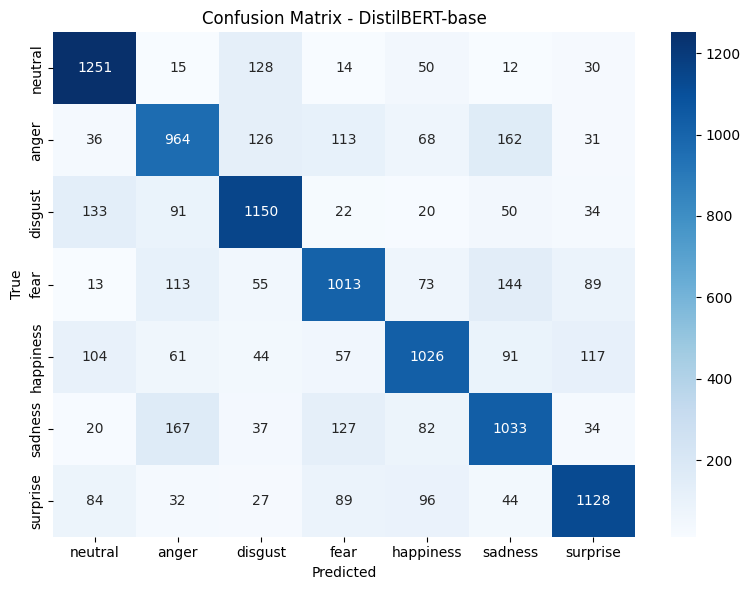

In [78]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - DistilBERT-base')
plt.tight_layout()
plt.show()

### DistilROBERTA base model

In [79]:
checkpoint = "transformer-models/distilroberta-base"
fallback = "distilbert/distilroberta-base"

model, tokenizer, trainer, train_ds, test_ds = load_or_train_model(
    base_checkpoint=checkpoint,
    fallback_checkpoint=fallback,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    show_params=True,
    unfreeze_classifier=True
)

Loading tokenizer and model from transformer-models/distilroberta-base...
Failed to load transformer-models/distilroberta-base, falling back to distilbert/distilroberta-base...


Map: 100%|██████████| 10500/10500 [00:00<00:00, 11266.66 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilbert/distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Freezing all parameters in the model body...
Unfreezing the final classification head (model.classifier/model.logits)...
✅ Total Trainable Parameters: 595975
Training new model...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,1.358300,1.338196,0.581714,0.571539
2,1.210100,1.169132,0.612476,0.604041
3,1.137200,1.093061,0.629524,0.623729
4,1.152000,1.057479,0.634381,0.627505
5,1.118100,1.030555,0.643619,0.636942
6,1.092400,1.017217,0.650667,0.644885
7,1.076300,1.004930,0.652381,0.647153
8,1.100100,1.006146,0.655524,0.649494
9,1.043800,0.992327,0.661048,0.655470
10,1.067700,0.991219,0.660667,0.656619


Saving trained model to transformer-models/distilroberta-base...


In [80]:
preds = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=-1)
y_true = np.array(test_ds["label"])

predictions["DistilROBERTA-base"] = y_pred

print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.760     0.870     0.811      1500
           1      0.664     0.479     0.557      1500
           2      0.697     0.831     0.758      1500
           3      0.647     0.637     0.642      1500
           4      0.633     0.623     0.628      1500
           5      0.556     0.659     0.603      1500
           6      0.695     0.547     0.612      1500

    accuracy                          0.664     10500
   macro avg      0.665     0.664     0.659     10500
weighted avg      0.665     0.664     0.659     10500



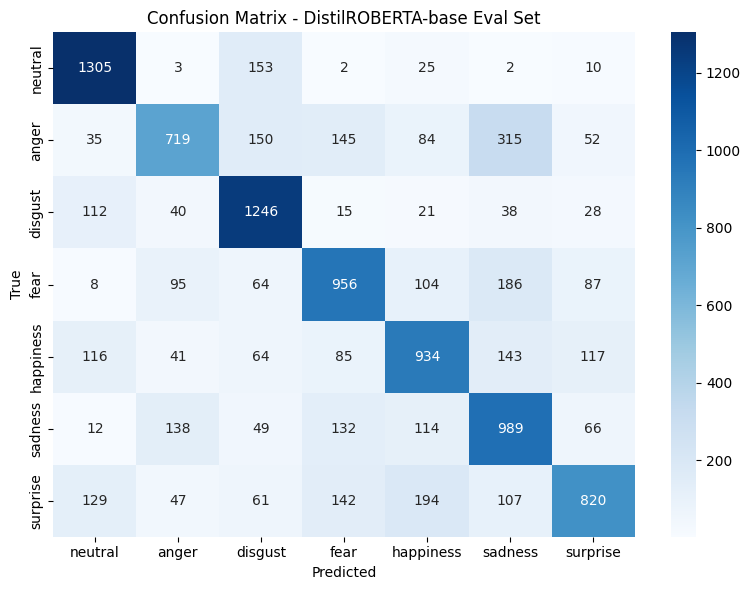

In [81]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - DistilROBERTA-base Eval Set')
plt.tight_layout()
plt.show()

In [17]:
checkpoint = "transformer-models/roberta-base-sentiment"
fallback = "cardiffnlp/twitter-roberta-base-sentiment-latest"

model, tokenizer, trainer, train_ds, test_ds = load_or_train_model(
    base_checkpoint=checkpoint,
    fallback_checkpoint=fallback,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    show_params=True,
    unfreeze_classifier=True
)

Loading tokenizer and model from transformer-models/roberta-base-sentiment...
Failed to load transformer-models/roberta-base-sentiment, falling back to cardiffnlp/twitter-roberta-base-sentiment-latest...


Map: 100%|██████████| 10500/10500 [00:00<00:00, 18535.86 examples/s]
Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest and are newly initialized because the shapes did not match:
- classi

Freezing all parameters in the model body...
Unfreezing the final classification head (model.classifier/model.logits)...
✅ Total Trainable Parameters: 595975
Training new model...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,1.047900,0.958233,0.652571,0.651860
2,0.985200,0.925069,0.666857,0.664030
3,0.988800,0.899184,0.677714,0.676746
4,0.984600,0.896200,0.676857,0.674410
5,0.974200,0.890229,0.679238,0.675948
6,0.947700,0.866669,0.690286,0.687920
7,0.956400,0.867188,0.688857,0.687673
8,0.954800,0.873071,0.685238,0.684343
9,0.933700,0.845139,0.698571,0.696037
10,0.946800,0.857739,0.690000,0.688974


Saving trained model to transformer-models/roberta-base-sentiment...


In [18]:
preds = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=-1)
y_true = np.array(test_ds["label"])

predictions["ROBERTA-base-sentiment"] = y_pred

print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.795     0.857     0.825      1500
           1      0.633     0.628     0.631      1500
           2      0.731     0.823     0.774      1500
           3      0.661     0.696     0.678      1500
           4      0.721     0.631     0.673      1500
           5      0.629     0.641     0.635      1500
           6      0.769     0.661     0.711      1500

    accuracy                          0.705     10500
   macro avg      0.706     0.705     0.704     10500
weighted avg      0.706     0.705     0.704     10500



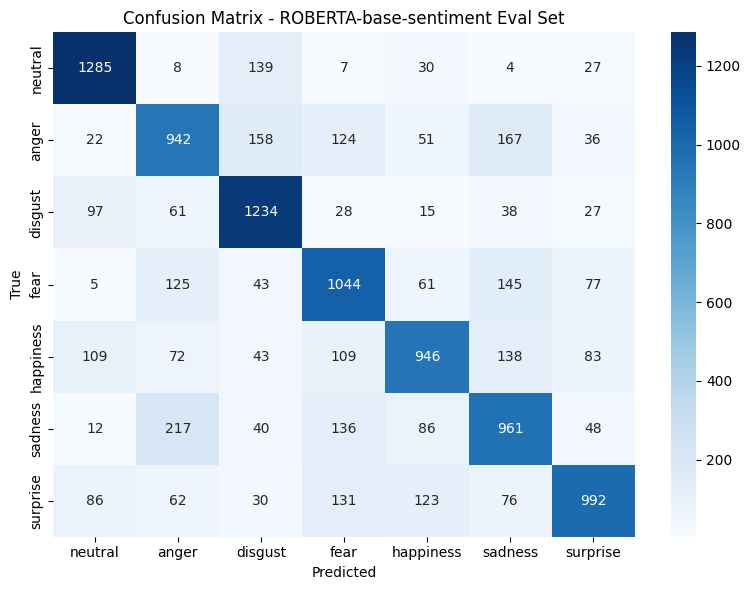

In [19]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - ROBERTA-base-sentiment Eval Set')
plt.tight_layout()
plt.show()

## Testing the best models 

In [20]:
from src.predict import PredictEngine

In [21]:
EMOTION_REVERSE_MAP = {v: k for k, v in EMOTION_MAP.items()}

In [22]:
df_test = pd.read_csv(r'../Data/CSV/final_transcript.csv')

In [23]:
columns_to_keep = ["Sentence", "Emotion_core"]

transformers_data = df_test[columns_to_keep].copy()

# Now safely map the labels
transformers_data["Emotion_core"] = transformers_data["Emotion_core"].map(EMOTION_REVERSE_MAP)

In [24]:
X, y = transformers_data['Sentence'], transformers_data['Emotion_core']

In [25]:
# distilbert_base = "transformer-models/distilbert-base"
# distilroberta = "transformer-models/distilroberta-base"
robertasentiment ="transformer-models/roberta-base-sentiment"

In [26]:
models = [robertasentiment]
predictions = {}

for model in models:
    # 1. Split the string by '/'
    parts = model.split('/')
    
    # 2. Get the last part, which is the model name (e.g., 'distilbert-base')
    model_name = parts[-1] 
    
    # Initialize and Run PredictEngine
    engine = PredictEngine(
        checkpoint=model,
        data_source=transformers_data,
        column="Sentence"
    )
    
    # Use the extracted model_name as the key in the predictions dictionary
    predictions[model_name] = engine.predict()

Map: 100%|██████████| 1227/1227 [00:00<00:00, 19557.62 examples/s]


In [27]:
y_true = np.array(y)

for model_name, y_pred in predictions.items():
    print(f'--- Results for {model_name} ---')
    
    # 1. Calculate F1 Score
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    # 2. Calculate Accuracy Score
    accuracy = accuracy_score(y_true, y_pred)
    
    print(f"The F1 score for the {model_name} model is {f1:.3f}")
    print(f"The accuracy for the {model_name} model is {accuracy:.3f}")

--- Results for roberta-base-sentiment ---
The F1 score for the roberta-base-sentiment model is 0.455
The accuracy for the roberta-base-sentiment model is 0.523
